In [41]:
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent))

In [42]:
%reload_ext autoreload
%autoreload 2



import numpy as np
import matplotlib.pyplot as plt
import importlib
import Measurments.state_to_edgepoints as state_to_edgepoints_module

state_to_edgepoints_module = importlib.reload(state_to_edgepoints_module)

In [43]:

from filters import ChristianRobinson 



from datetime import datetime
from dataclasses import dataclass
import pytz
from enum import Enum

from utils import circle_points, camera_view, noise
from classes import Camera, Body, PlanetImage, Pose

from filters import SatEKF


from Measurments.InterfaceWrapperFuncs import Set_camera, gen_traj, plot_traj, get_images,run_step, get_tpc, plot_est_dist_xyz, plot_est_dist_xyz_errors, plot_trajs

In [44]:
f, mu, n_pixels = Set_camera() #Sagitta camera parameters


# One-time calculation
camera = Camera(f, mu, n_pixels)
camera.calc_specs()
moon_radius = 1737.4 # km
moon_mu = 4902.800066 # km^3/s^2

body = Body(a=moon_radius, b=moon_radius, c=moon_radius)
#print(camera)
print(body)


w, h = 1280, 720
K = np.array(
    [
        [1120.0, 0.0, w / 2.0],
        [0.0, 1120.0, h / 2.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

k_inv = np.linalg.inv(K)

camera_spec_ellie = {
    "K": K,
    "width": w,
    "height": h,
}

camera_spec_ellie2 = {
    "K": np.linalg.inv(camera.K_inv),
    "width": camera.resolution[0],
    "height": camera.resolution[1],
}

cr_alg = ChristianRobinson(k_inv, body.a, body.b, body.c)


Worldview:
 - Ellipsoid semi-axes a,b,c = [1737.4, 1737.4, 1737.4] km



Orbital period (T): 45980.8058633618s


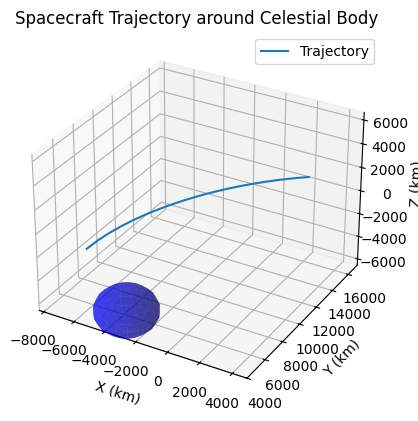

24
0


In [45]:
pos = np.array([-5000, 4000, 100])
r = np.linalg.norm(pos)
v = np.sqrt( moon_mu / r) + 0.2 # km/s, slightly
State0 = [pos[0], pos[1], pos[2], 0, v, 0] 



dt = 1000
op, body_struct = gen_traj(Starting_state=State0, dt=dt)
plot_traj(op.states, body_struct)

print(len(op.states))
print(op.ts[0])


In [46]:
# for 10 points along traj gen images and test CR alg
cam_offset = np.array([0, 0, 0]) # no offset for now
images, edges, outs, states, times = get_images(op.states, op.ts, body_struct, cam_offset, camera_spec_ellie, 10)


State at t=0.0s: [-5.000e+03  4.000e+03  1.000e+02  0.000e+00  1.075e+00  0.000e+00]
State at t=1000.0s: [-4.958e+03  5.038e+03  9.916e+01  8.034e-02  1.002e+00 -1.607e-03]
State at t=2000.0s: [-4.846e+03  6.007e+03  9.692e+01  1.401e-01  9.355e-01 -2.802e-03]
State at t=3000.0s: [-4.682e+03  6.911e+03  9.365e+01  1.853e-01  8.743e-01 -3.707e-03]
State at t=4000.0s: [-4.479e+03  7.757e+03  8.958e+01  2.201e-01  8.188e-01 -4.402e-03]
State at t=5000.0s: [-4.245e+03  8.551e+03  8.490e+01  2.472e-01  7.683e-01 -4.944e-03]
State at t=6000.0s: [-3.986e+03  9.295e+03  7.973e+01  2.685e-01  7.222e-01 -5.370e-03]
State at t=7000.0s: [-3.709e+03  9.996e+03  7.418e+01  2.854e-01  6.800e-01 -5.707e-03]
State at t=8000.0s: [-3.417e+03  1.066e+04  6.834e+01  2.988e-01  6.412e-01 -5.976e-03]
State at t=9000.0s: [-3.113e+03  1.128e+04  6.225e+01  3.095e-01  6.053e-01 -6.190e-03]


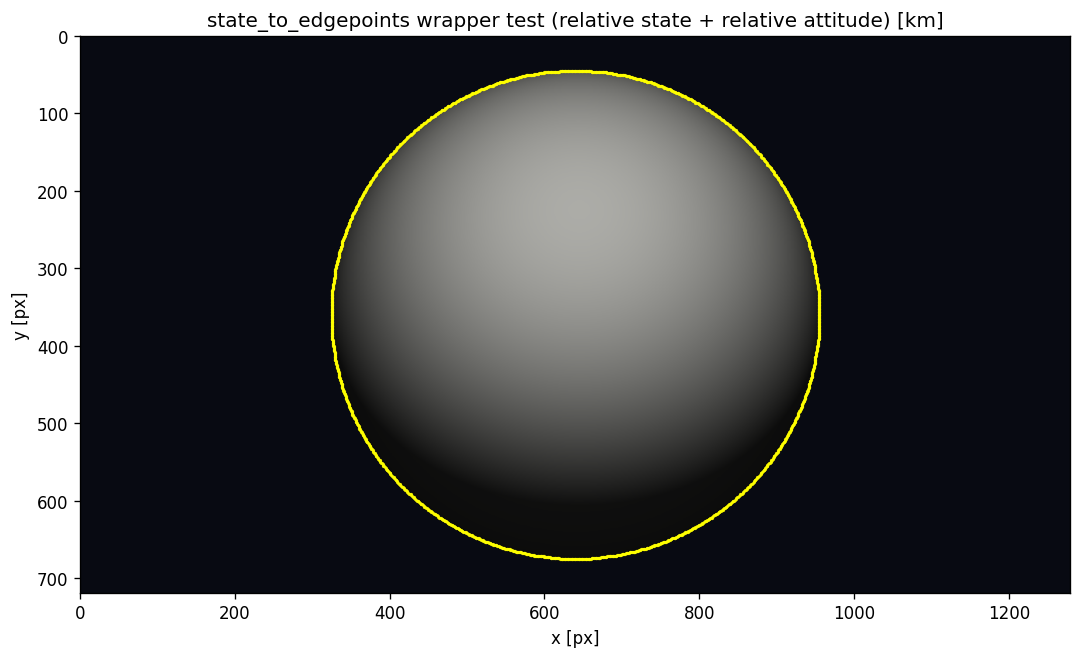

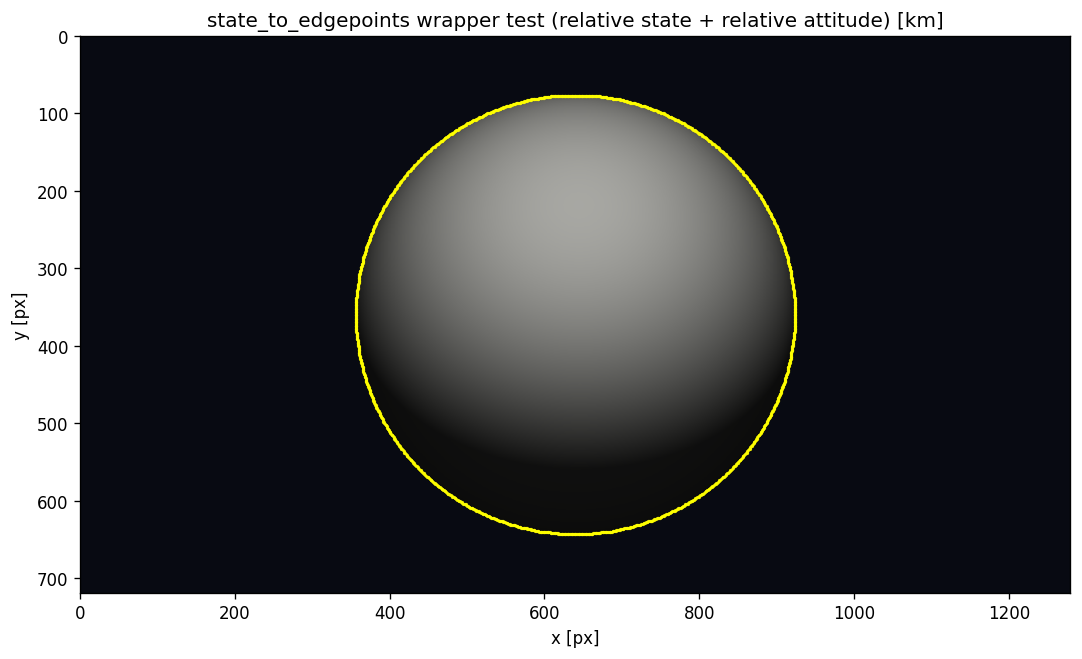

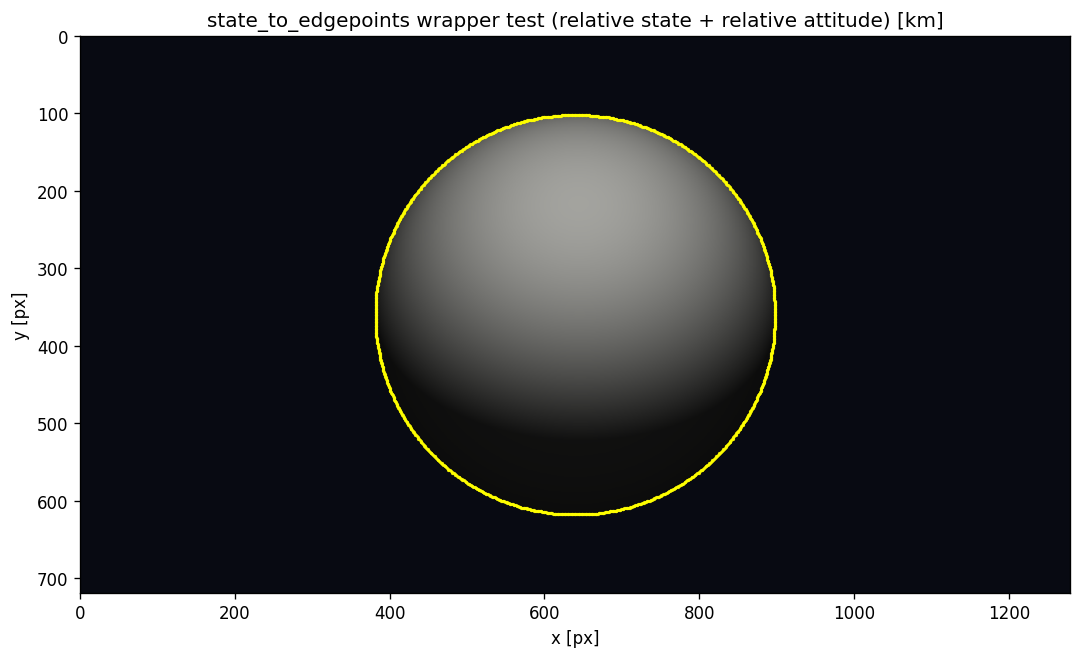

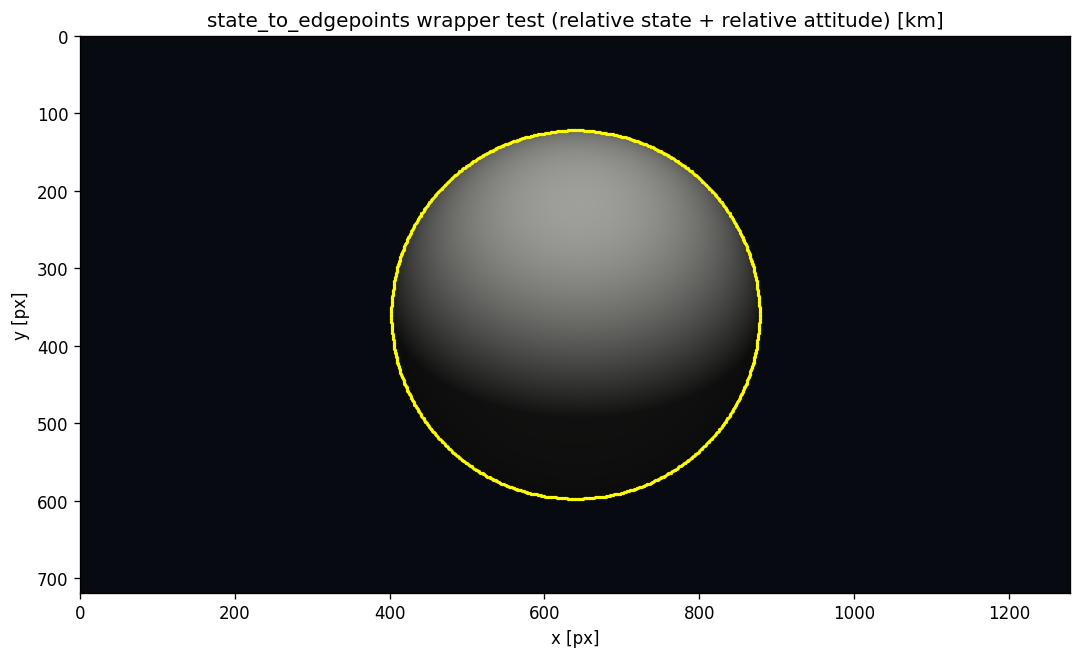

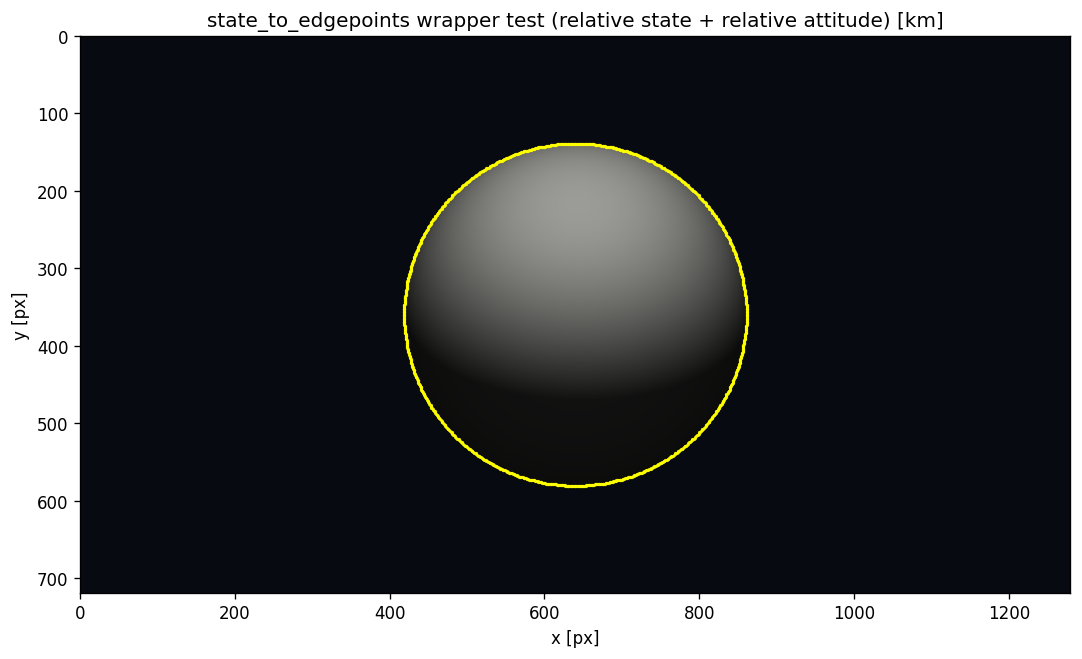

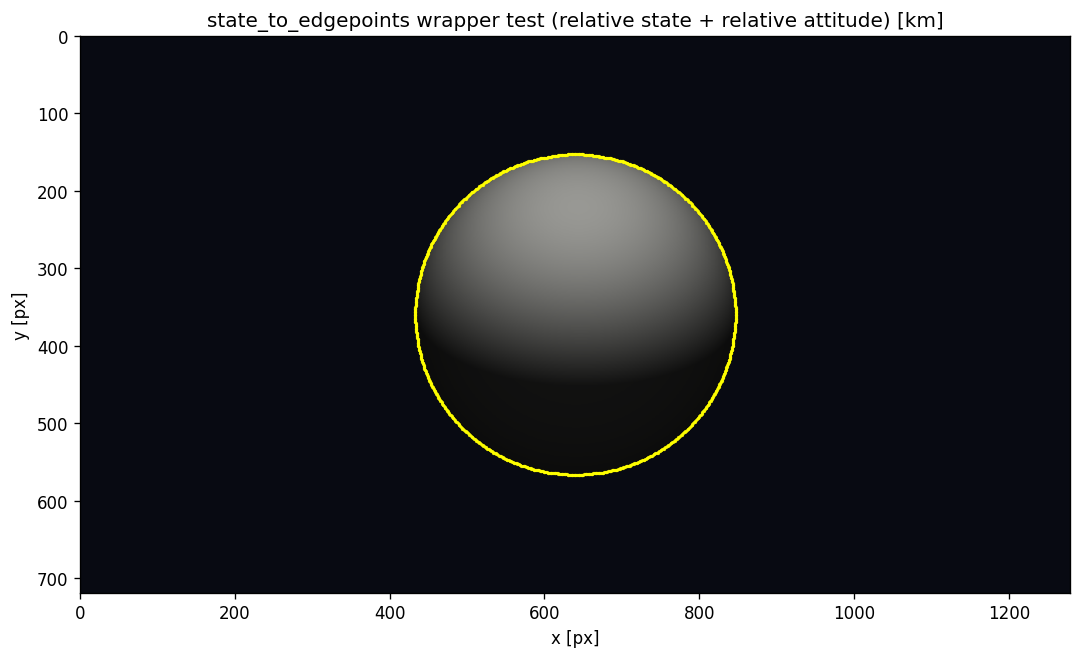

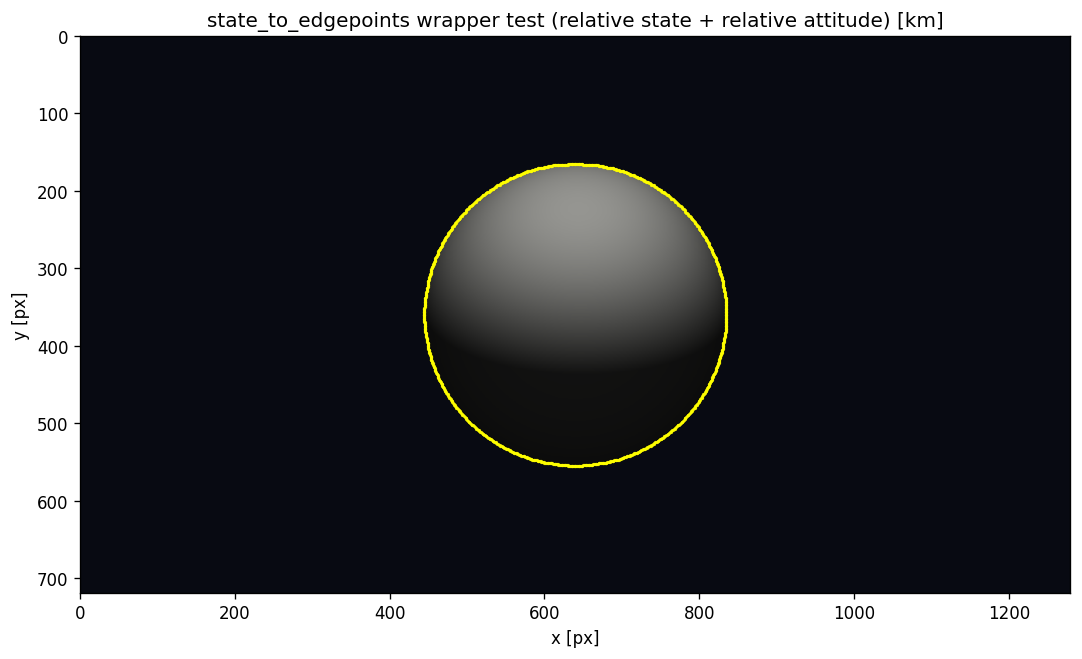

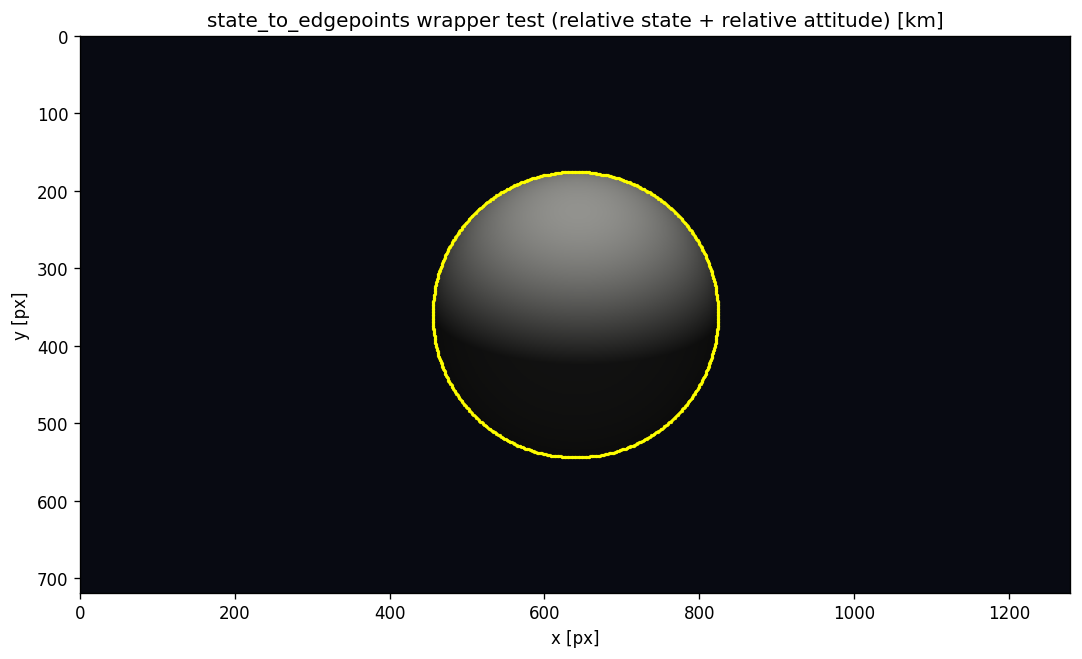

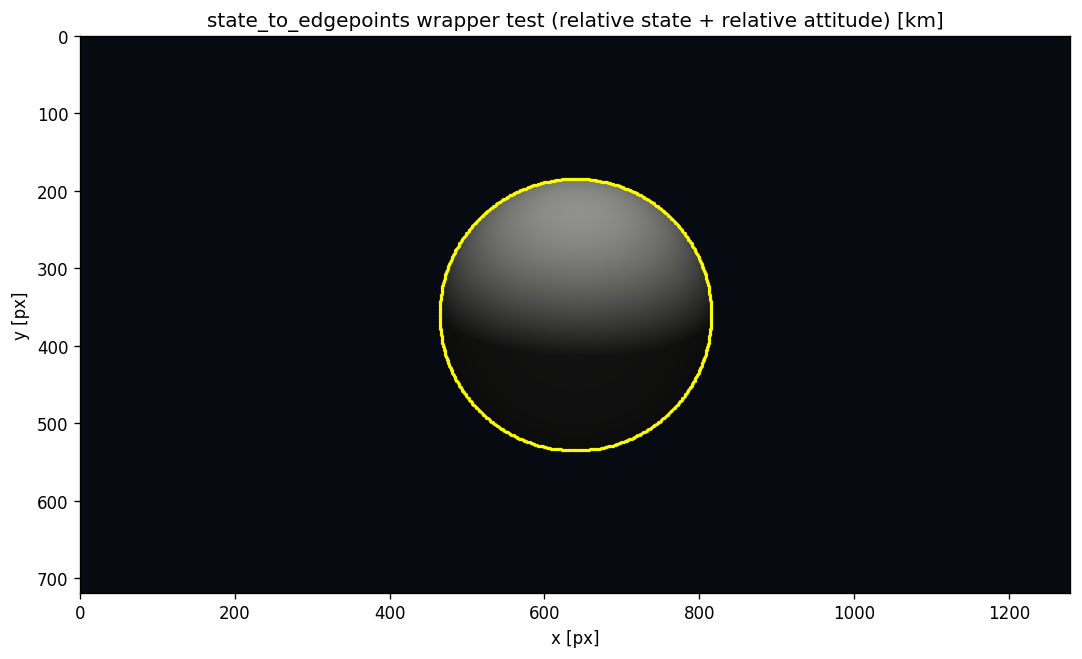

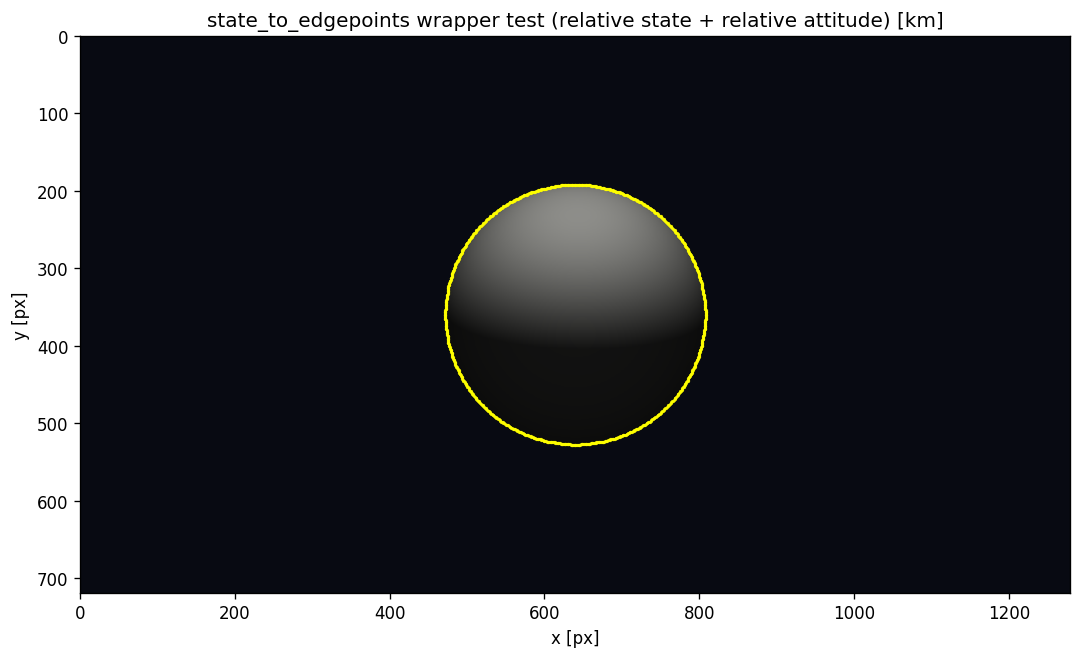

In [47]:

i = 0
for out in outs:
    i += 1
    if i % 1 == 0:
        w, h = camera_spec_ellie["width"], camera_spec_ellie["height"]
        state_to_edgepoints_module.plot_edge_points(
            out,
            w,
            h,
            x_limits=None,
            y_limits=None,
        )

In [48]:

# Running Christian-Robinson algorithm on all images
# Note: Camera offset is now handled in get_images() via attitude_offset_from_center_pointing

estimates = []
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute planet-to-camera rotation matrix from render output
    tpc = get_tpc(out)
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: estimates camera->planet vector in camera frame
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], tpc, print_stats=True, cr_alg=cr_alg)
    estimates.append(-rp_est)

Running CR alg on image 1/10
Calc Position:
 - (C->P in camera frame): [   0.      0.   6413.39] (6413.39 km)
 - (C->P in planet frame): [ 5007.4  -4005.92  -100.15] (6413.39 km)
Actual position:
 - (C->P in camera frame): [  -0.     -0.   6403.91] (6403.91 km)
 - (C->P in planet frame): [ 5000. -4000.  -100.] (6403.91 km)
Est Error - Actual:
 - (Camera frame): [0.   0.   9.48] (9.48 km)
 - (Planet frame): [ 7.4  -5.92 -0.15] (9.48 km)
Distance error: 9.48 km (0.148060%)
Angular error: 0.0000 degrees
Running CR alg on image 2/10
Calc Position:
 - (C->P in camera frame): [   0.      0.   7081.89] (7081.89 km)
 - (C->P in planet frame): [ 4966.66 -5047.35   -99.33] (7081.89 km)
Actual position:
 - (C->P in camera frame): [  -0.      0.   7069.25] (7069.25 km)
 - (C->P in planet frame): [ 4957.79 -5038.34   -99.16] (7069.25 km)
Est Error - Actual:
 - (Camera frame): [ 0.    0.   12.64] (12.64 km)
 - (Planet frame): [ 8.87 -9.01 -0.18] (12.64 km)
Distance error: 12.64 km (0.178826%)
Angula

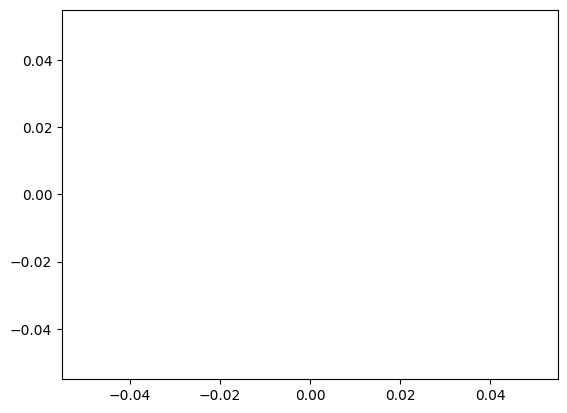

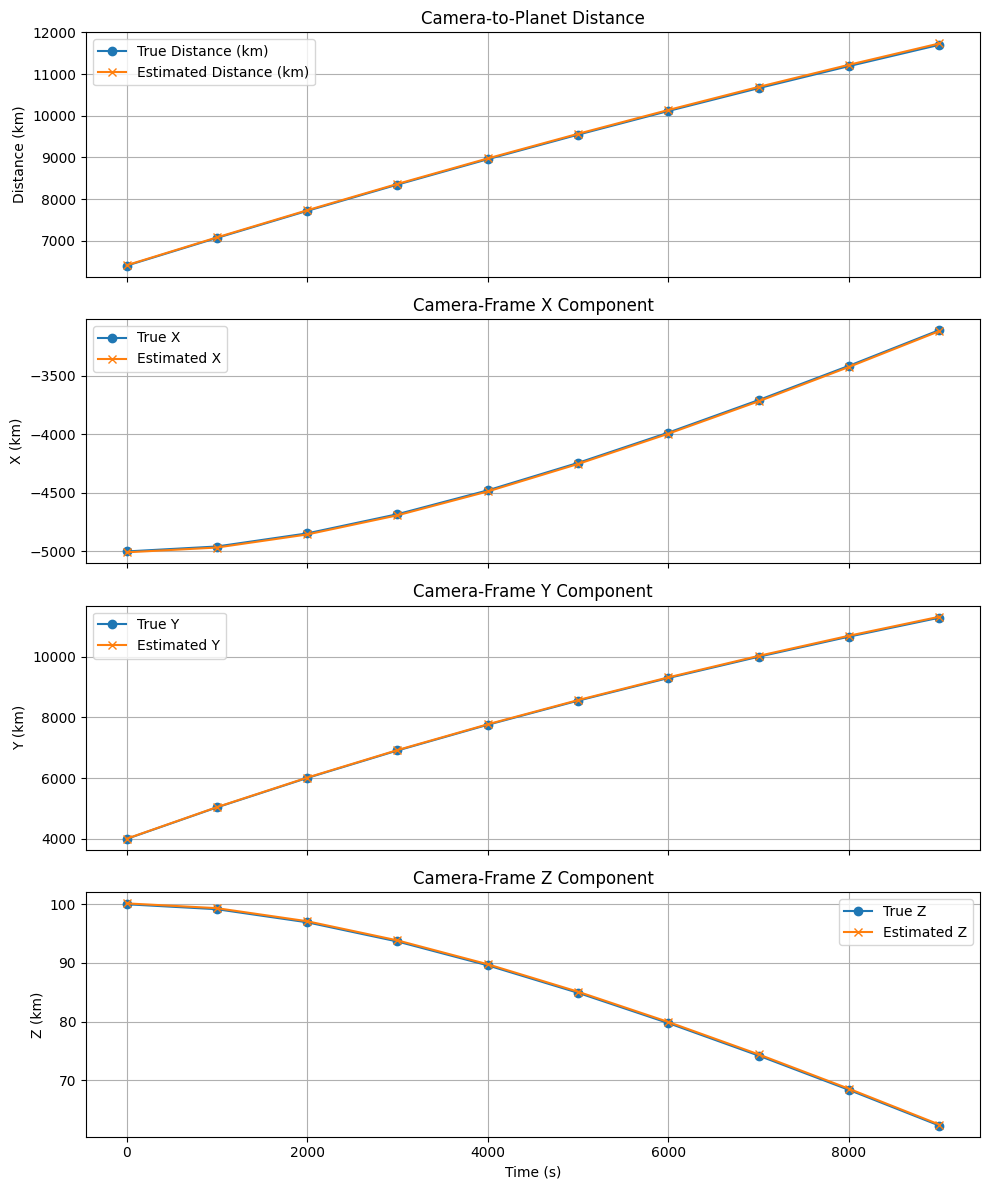

In [49]:
# compare true/estimated camera-frame vectors and distances with optional axis limits
states = np.array(states)
pos = states[:, 0:3]
estimates = np.array(estimates)
times = np.array(times)

#print(np.shape(pos))
#print(estimates[:, 1])
#print("times:", times)

plt.plot()


plot_est_dist_xyz(
    times,
    pos,
    estimates,
    
)

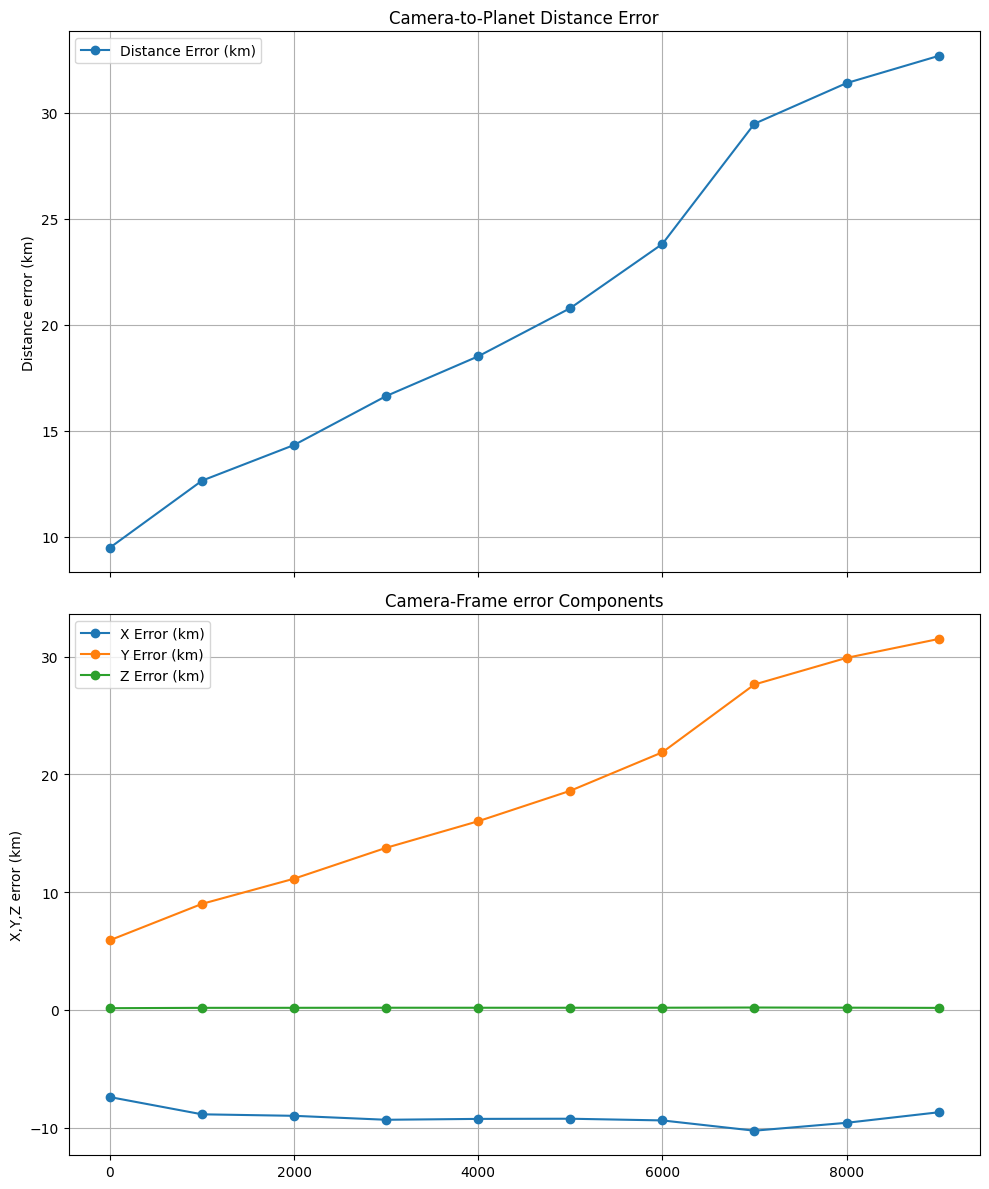

In [50]:
plot_est_dist_xyz_errors(
    times,
    pos,
    estimates,
)

In [51]:
# EKF time
Q = np.diag([1,1, 1, 0.0001, 0.0001, 0.0001])  # Process noise covariance

Q_perfect = np.zeros((6, 6))  # Perfect process model (no noise)

R_1 = 1000


R = np.diag([R_1, R_1, R_1])  # Measurement noise covariance
dt = 1000.0  # Time step in seconds
t = 0 
N = 50

state_0 = np.array(State0)
mu0 = state_0
sigma0 = np.diag([1.0, 1.0, 1.0,  0.0001, 0.0001, 0.0001])  # Initial state covariance

central_body_mass = 7.34767309e22

ekf = SatEKF(Q, R, dt, mu0, sigma0, central_body_mass)



[-5.000e+03  4.000e+03  1.000e+02  0.000e+00  1.075e+00  0.000e+00]


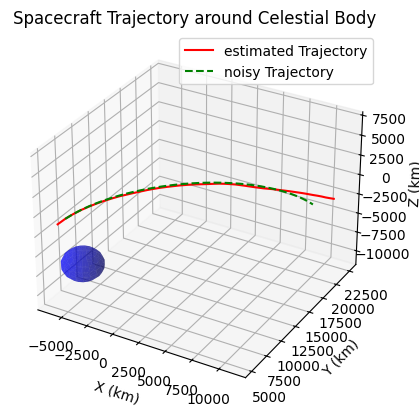

In [52]:
state = np.array(state_0)
print(state)
states_noisy = [state]
states_perfect = []
state_clean = state

# get noisy trajectory for EKF testing
for i in range(N):
    process_noise = np.random.multivariate_normal(np.zeros(6), Q)
    state_next_perfect= ekf.f_func(state_clean) 
    state_next_noisy = ekf.f_func(state) + process_noise
    t += dt
    states_perfect.append(state_next_perfect)
    states_noisy.append(state_next_noisy)
    state = state_next_noisy
    state_clean = state_next_perfect

states_noisy = np.array(states_noisy)
states_perfect = np.array(states_perfect)

ts = np.arange(0, N*dt, dt)

plot_trajs(states_noisy, states_perfect, body_struct)

In [ ]:
# get CR estimates for EKF measurement updates
print(ts[i])
print(states_noisy[i])
cam_offset = np.array([0, 0, 0]) # no offset for now
images, edges, outs, states, times = get_images(states_noisy, ts, body_struct, cam_offset, camera_spec_ellie, N)


49000.0
[ 9.758e+03  2.357e+04 -3.918e+03  2.999e-01  1.947e-01 -1.006e-01]
State at t=0.0s: [-5.000e+03  4.000e+03  1.000e+02  0.000e+00  1.075e+00  0.000e+00]
State at t=1000.0s: [-4.953e+03  5.036e+03  1.004e+02  9.275e-02  1.001e+00 -1.119e-02]
State at t=2000.0s: [-4.827e+03  6.002e+03  8.870e+01  1.570e-01  9.425e-01 -2.185e-02]
State at t=3000.0s: [-4.645e+03  6.911e+03  6.641e+01  1.951e-01  8.832e-01 -4.446e-02]
State at t=4000.0s: [-4.431e+03  7.765e+03  2.013e+01  2.316e-01  8.165e-01 -4.386e-02]
State at t=5000.0s: [-4.182e+03  8.554e+03 -2.353e+01  2.569e-01  7.755e-01 -5.367e-02]
State at t=6000.0s: [-3.915e+03  9.304e+03 -7.663e+01  2.800e-01  7.309e-01 -5.394e-02]
State at t=7000.0s: [-3.626e+03  1.001e+04 -1.308e+02  2.834e-01  6.820e-01 -5.756e-02]
State at t=8000.0s: [-3.336e+03  1.067e+04 -1.881e+02  3.064e-01  6.378e-01 -7.471e-02]
State at t=9000.0s: [-3.022e+03  1.130e+04 -2.645e+02  3.219e-01  6.098e-01 -5.402e-02]
State at t=10000.0s: [-2.695e+03  1.189e+04 -3.

In [ ]:
estimates_p = [] # Estimates in PLANET FRAME
estimates_c = [] # Estimates in CAMERA FRAME
tpcs = []
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute planet-to-camera rotation matrix from render output
    tpc = get_tpc(out)
    tpcs.append(tpc)
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: estimates camera->planet vector in camera frame
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], tpc, print_stats=True, cr_alg=cr_alg)
    estimates_p.append(rp_est)
    estimates_c.append(rc_est)

estimates_c = np.array(estimates_c)
estimates_p = np.array(estimates_p)

Running CR alg on image 1/50
Calc Position:
 - (C->P in camera frame): [   0.      0.   6413.39] (6413.39 km)
 - (C->P in planet frame): [ 5007.4  -4005.92  -100.15] (6413.39 km)
Actual position:
 - (C->P in camera frame): [  -0.     -0.   6403.91] (6403.91 km)
 - (C->P in planet frame): [ 5000. -4000.  -100.] (6403.91 km)
Est Error - Actual:
 - (Camera frame): [0.   0.   9.48] (9.48 km)
 - (Planet frame): [ 7.4  -5.92 -0.15] (9.48 km)
Distance error: 9.48 km (0.148060%)
Angular error: 0.0000 degrees
Running CR alg on image 2/50
Calc Position:
 - (C->P in camera frame): [   0.      0.   7075.64] (7075.64 km)
 - (C->P in planet frame): [ 4960.44 -5044.7    -98.1 ] (7075.64 km)
Actual position:
 - (C->P in camera frame): [  -0.     -0.   7064.28] (7064.28 km)
 - (C->P in planet frame): [ 4952.48 -5036.61   -97.94] (7064.28 km)
Est Error - Actual:
 - (Camera frame): [ 0.    0.   11.35] (11.35 km)
 - (Planet frame): [ 7.96 -8.09 -0.16] (11.35 km)
Distance error: 11.35 km (0.160700%)
Angula

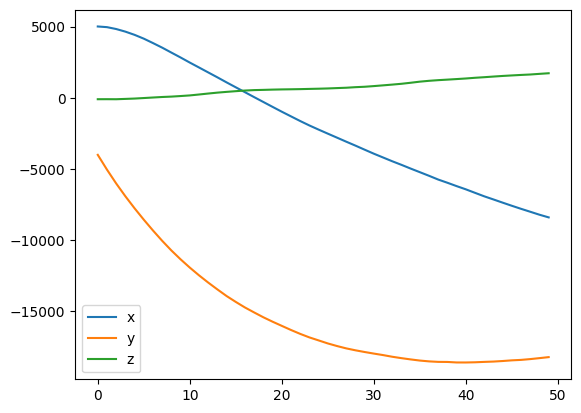

In [ ]:
# plt.plot(estimates_p)
# plt.plot(estimates_c[:,2])
plt.plot(estimates_p)
plt.legend(["x", "y", "z"])

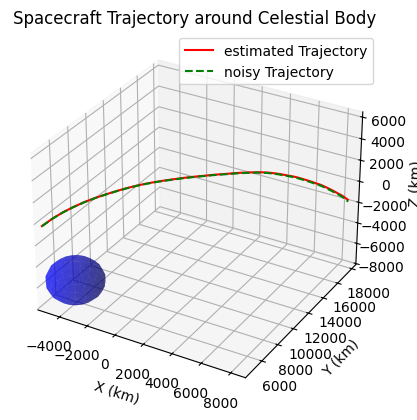

In [ ]:
estimates_p = np.array(estimates_p)

plot_trajs(-estimates_p, states_noisy, body_struct)

In [ ]:
# now its kalman filtering time
tpcs = np.array(tpcs)
mus = [mu0]
sigmas = [sigma0]
for i in range(N):
    print(f"EKF step {i+1}/{N}")
    ekf.predict()
    print("meauments", -estimates_c[i])
    print("Predicted state:", ekf.mu)
    ekf.update(-estimates_c[i],tpcs[i])
    mus.append(ekf.mu)
    sigmas.append(ekf.sigma)


print("Final EKF state estimate:", ekf.mu)

EKF step 1/50
meauments [-3.268e-13 -1.634e-13 -6.413e+03]
Predicted state: [-4.953e+03  5.038e+03  9.907e+01  9.336e-02  1.000e+00 -1.867e-03]
Measurement function output: [ 1.421e-14 -8.395e+02 -7.016e+03]
EKF step 2/50
meauments [-8.527e-14 -5.258e-13 -7.076e+03]
Predicted state: [-4.834e+03  5.814e+03  9.669e+01  1.593e-01  8.361e-01 -3.187e-03]
Measurement function output: [-1.079e+00 -6.289e+02 -7.535e+03]
EKF step 3/50
meauments [-5.684e-13 -4.121e-13 -7.714e+03]
Predicted state: [-4.706e+03  6.223e+03  9.357e+01  1.961e-01  6.206e-01 -4.129e-03]
Measurement function output: [ 5.198e+00 -2.254e+02 -7.800e+03]
EKF step 4/50
meauments [-6.324e-13  1.279e-12 -8.332e+03]
Predicted state: [-4.569e+03  6.665e+03  9.433e+01  2.203e-01  5.105e-01 -3.478e-03]
Measurement function output: [  -17.449    77.155 -8081.425]
EKF step 5/50
meauments [-5.684e-14  1.492e-13 -8.930e+03]
Predicted state: [-4.389e+03  7.337e+03  7.853e+01  2.430e-01  5.054e-01 -7.569e-03]
Measurement function output

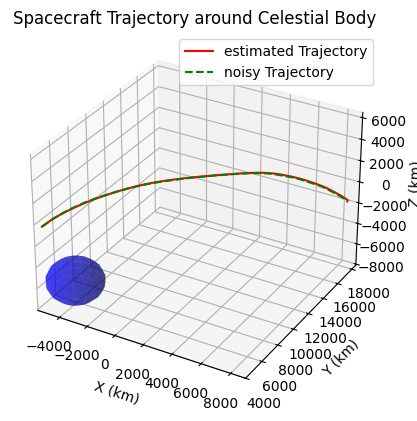

In [ ]:
mus = np.array(mus)
sigmas = np.array(sigmas)
plot_trajs(mus, states_noisy, body_struct)


Final EKF state estimate: [ 8.403e+03  1.820e+04 -1.718e+03  1.949e-01 -8.185e-02 -3.657e-02]


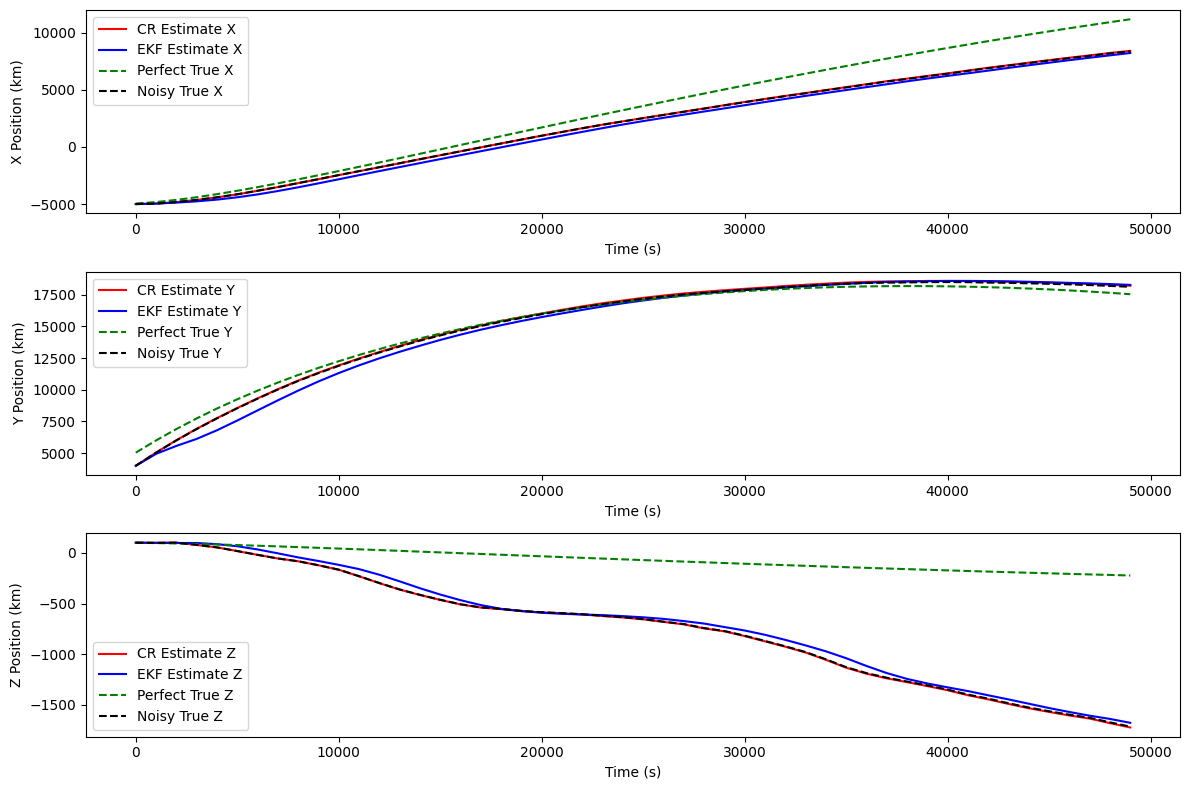

In [ ]:
# plot EKF estimates vs true trajectory and CR estimates vs time
mus = np.array(mus)
states_noisy = np.array(states_noisy)
    

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
print("Final EKF state estimate:", ekf.mu)
plt.plot(ts, -estimates_p[:, 0], label='CR Estimate X', color='r')
# Align array lengths with ts (mus and states_noisy are length 51, ts is 50)
mus = mus[:len(ts)]
states_noisy = states_noisy[:len(ts)]
plt.plot(ts, mus[:, 0], label='EKF Estimate X', color='b')
plt.plot(ts, states_perfect[:, 0], label='Perfect True X', color='g', linestyle='--')
plt.plot(ts, states_noisy[:, 0], label='Noisy True X', color='k', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('X Position (km)')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(ts, -estimates_p[:, 1], label='CR Estimate Y', color='r')
plt.plot(ts, mus[:, 1], label='EKF Estimate Y', color='b')
plt.plot(ts, states_perfect[:, 1], label='Perfect True Y', color='g', linestyle='--')
plt.plot(ts, states_noisy[:, 1], label='Noisy True Y', color='k', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Y Position (km)')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(ts, -estimates_p[:, 2], label='CR Estimate Z', color='r')
plt.plot(ts, mus[:, 2], label='EKF Estimate Z', color='b')
plt.plot(ts, states_perfect[:, 2], label='Perfect True Z', color='g', linestyle='--')
plt.plot(ts, states_noisy[:, 2], label='Noisy True Z', color='k', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Z Position (km)')
plt.legend()
plt.tight_layout()
plt.show()